In [ ]:
!pip install nltk

In [ ]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import time
import unicodedata
from collections import defaultdict
from datetime import datetime
from types import NoneType
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from underthesea import word_tokenize as vi_tokenizer
from nltk.corpus import stopwords
import nltk
from nltk.tokenize import word_tokenize as en_tokenizer

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## Đọc file

In [ ]:
data = pd.read_csv('/content/drive/My Drive/Đồ án/Bronze_data.csv', encoding='utf-8')

## Xử lý

In [ ]:
data.head()

,Name,Address,Distance_to_DownTown,Distance_to_Beach,Price,Taxes,Kind,Point,Evaluate,Stars,...,comfort,worthwhile,destination,distance_to_airport,airport_shuttle,Adults,Children,Checkin,Checkout,Crawl_date
0,Corgi House Danang,"Sông Hàn, Đà Nẵng",Cách trung tâm 400m,"Cách bãi biển 1,7km",VND 475.000,Đã bao gồm thuế và phí,Phòng Superior Giường Đôi,"8,1",Rất tốt,NaN,...,"8,3","8,8","9,4","Sân bay Quốc tế Đà Nẵng - 3,9 km\nSân bay quốc...",1.0,1,0,2025-05-15,2025-05-16,2025-04-30
1,Ngoc Bich hotel,"Bãi biển Mỹ Khê, Đà Nẵng","Cách trung tâm 1,8km",Giáp biển,VND 242.338,+VND 32.242 thuế và phí,Phòng Đôi Superior,"8,0",Rất tốt,3.0,...,"7,9","8,3","8,7",Sân bay Quốc tế Đà Nẵng - 6 km\nSân bay quốc t...,1.0,1,0,2025-05-15,2025-05-16,2025-04-30
2,La Belle Vie Boutique Hotel,"Vịnh Đà Nẵng, Đà Nẵng","Cách trung tâm 1,3km","Cách bãi biển 2,4km",VND 450.000,+VND 58.500 thuế và phí,Phòng Superior Giường Đôi,"8,9",Tuyệt vời,4.0,...,"8,9","9,1","8,7",Sân bay Quốc tế Đà Nẵng - 5 km\nSân bay quốc t...,1.0,1,0,2025-05-15,2025-05-16,2025-04-30
3,LaDa's House Da Nang,"Trung tâm Thành phố Đà Nẵng, Đà Nẵng",Ở trung tâm thành phố,"Cách bãi biển 2,4km",VND 806.841,Đã bao gồm thuế và phí,Phòng Deluxe Giường Đôi Có Ban Công,"9,0",Tuyệt hảo,NaN,...,"9,2","9,2","9,2","Sân bay Quốc tế Đà Nẵng - 2,6 km\nSân bay quốc...",1.0,1,0,2025-05-15,2025-05-16,2025-04-30
4,Dana Boutique Hotel & Apartment,"Bãi biển Mỹ Khê, Đà Nẵng","Cách trung tâm 1,4km",Giáp biển,VND 524.200,+VND 70.205 thuế và phí,Studio Có Giường Cỡ King,"8,8",Tuyệt vời,4.0,...,"9,0","8,9","8,9","Sân bay Quốc tế Đà Nẵng - 4,9 km\nSân bay quốc...",1.0,1,0,2025-05-15,2025-05-16,2025-04-30


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282507 entries, 0 to 282506
Data columns (total 34 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Name                  282504 non-null  object 
 1   Address               282504 non-null  object 
 2   Distance_to_DownTown  282501 non-null  object 
 3   Distance_to_Beach     163964 non-null  object 
 4   Price                 282129 non-null  object 
 5   Taxes                 282129 non-null  object 
 6   Kind                  282086 non-null  object 
 7   Point                 276870 non-null  object 
 8   Evaluate              276870 non-null  object 
 9   Stars                 240821 non-null  float64
 10  Rates_Quantity        276870 non-null  object 
 11  view_to_beach         282238 non-null  float64
 12  view_to_city          282238 non-null  float64
 13  view_to_mountain      282238 non-null  float64
 14  view_to_river         282238 non-null  float64
 15  

In [ ]:
df = data.copy()

### Xử lý tổng thể file  
- Xóa các khoảng trắng đầu cuối của các giá trị.  
- Chuyển đổi các giá trị khoảng trống thành nan để tiện cho việc xử lý sau này.  
- Trực quan hóa missing values và loại bỏ dòng nếu thuộc tính có tỉ lệ missing <5%.  
- Xóa các giá trị bị trùng lặp.  

In [ ]:
#Xóa các dòng trống trong df
df = df.dropna(how='all')

# Xóa khoảng trắng đầu cuối
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].str.strip()

#replace giá trị khoảng trắng thành nan
df = df.replace(r'^\s*$', pd.NA, regex=True)

#Xóa các giá trị trùng lặp
df = df.drop_duplicates()

In [ ]:
#Kiểm tra missing values
def missing_values(df, sort=True, ascending=False):
    total_missing = df.isnull().sum()
    percent_missing = 100 * total_missing / len(df)
    missing_df = pd.DataFrame({
        'Missing Count': total_missing,
        'Missing Percent': percent_missing
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0]

    if sort:
        missing_df = missing_df.sort_values(by='Missing Percent', ascending=ascending)

    return missing_df

missing_values(df)

,Missing Count,Missing Percent
Distance_to_Beach,117690,41.864833
Stars,41478,14.754606
distance_to_airport,29967,10.659898
convenient,5839,2.077056
worthwhile,5839,2.077056
destination,5839,2.077056
comfort,5839,2.077056
clean,5839,2.077056
staff,5839,2.077056
Evaluate,5615,1.997375


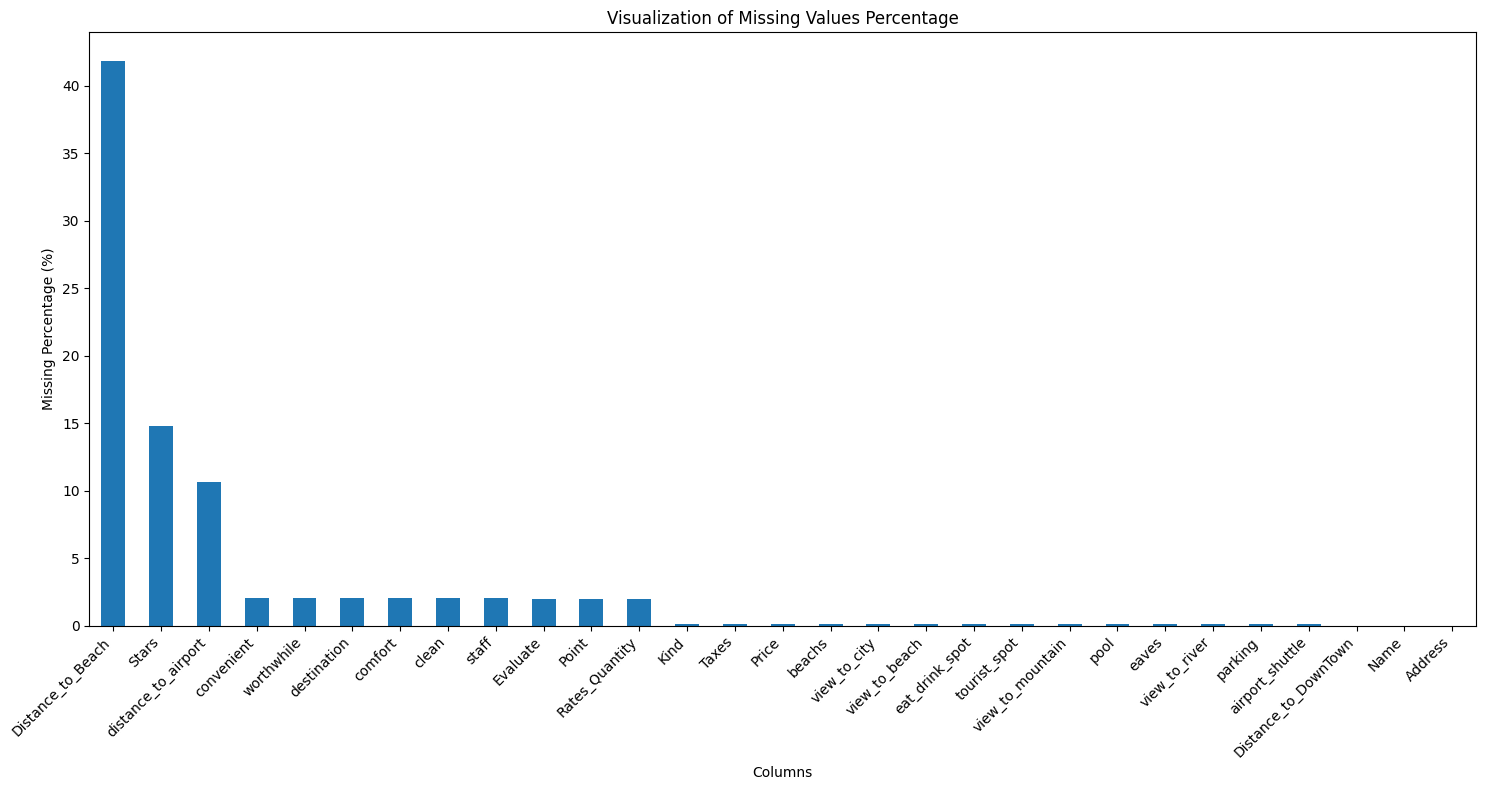

In [ ]:
# Hàm trực quan hóa missing values
def plot_missing_values(df, sort=True, ascending=False):
    missing_df = missing_values(df, sort=sort, ascending=ascending)

    if not missing_df.empty:
        plt.figure(figsize=(15, 8))
        missing_df['Missing Percent'].plot(kind='bar')
        plt.title('Visualization of Missing Values Percentage')
        plt.xlabel('Columns')
        plt.ylabel('Missing Percentage (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print("No missing values to visualize.")

plot_missing_values(df)

In [ ]:
# Lấy tên các cột có tỉ lệ missing < 5%
cols_to_drop_rows = missing_values(df).index[missing_values(df)['Missing Percent'] < 5].tolist()

# Xóa các dòng bị missing trong các cột đã chọn
df = df.dropna(subset=cols_to_drop_rows)

# Kiểm tra lại missing values sau khi xóa
(missing_values(df))

,Missing Count,Missing Percent
Distance_to_Beach,114802,41.767597
Stars,37510,13.646997
distance_to_airport,29525,10.741871


### Xử lý đặc trưng địa chỉ
- Chuyển các kí tự từ dạng NFD(ký tự gốc + dấu tách rời) thành dạng NFC(ký tự có dấu đã được ghép lại).  
- Trích xuất ra khu vực đặc trưng nhất của địa chỉ(10 khu vực lớn của các khu vực biển Việt Nam).   
- Sử dụng Onehot Encoding cho đặc trưng 'Address'

In [ ]:
# Address
Main_location_list = ['đà nẵng', 'nha trang','phú quốc','mũi né','vũng tàu','hội an', 'quy nhơn', 'hạ long', 'đảo cát bà','đồng hới']

def normalize_text(text):
    # Tách dấu với NFD
    text = unicodedata.normalize('NFD', text)
    # Loại bỏ các dấu phụ
    text = re.sub(r'[\u0300-\u036f]', '', text)
    # Thay thế các ký tự đặc biệt
    text = text.replace('đ', 'd').replace('Đ', 'D').replace('ð', 'd').replace('Ð', 'D')
    # Chuyển thành chữ thường và loại bỏ khoảng trắng thừa
    return text.lower().strip()

def extract_main_location(address):
    # Kiểm tra giá trị không hợp lệ
    if pd.isna(address) or not address or address.strip() == '':
        return None

    # Tách địa chỉ, loại bỏ khoảng trắng thừa và dấu phẩy kép
    address = re.sub(r',\s*,+', ',', address.strip())
    parts = re.split(r',\s*', address)

    # Lấy phần cuối cùng (địa điểm chính)
    main_part = parts[-1] if parts else None

    # Loại bỏ phần trong ngoặc
    main_part = re.split(r'\s*\(', main_part)[0].strip()

    # Chuẩn hóa văn bản
    main_part = normalize_text(main_part)

    # Kiểm tra nếu main_part rỗng
    return main_part if main_part else None

# Tạo ánh xạ từ dạng dính liền -> dạng có khoảng trắng
mapping = {}
for loc in Main_location_list:
    norm = normalize_text(loc)
    compact = norm.replace(' ', '')
    mapping[compact] = norm

#Sửa lỗi các giá trị bị dính liền
def fix_compact_locations(addr):
    if pd.isna(addr):
        return None
    addr_compact = addr.replace(' ', '')
    return mapping.get(addr_compact, addr)

#Trích xuất địa chỉ
df['Address'] = df['Address'].apply(extract_main_location)

#Sửa lỗi bị dính liền
df['Address'] = df['Address'].apply(fix_compact_locations)

### Xử lý các đặc trưng về khoảng cách.
- Trích xuất ra đặc trưng về khoảng cách (số) và đơn vị khoảng cách (m/km).    
- Đưa về chung 1 đơn vị là km.
- Áp dụng với đặc trưng 'Distance_to_DownTown', 'Distance_to_Beach', 'distance_to_airport.  
- Đối với đặc trưng distance_to_airport, tạo ra 2 đặc trưng khác là  'count_nearest_airport' (số lượng sân bay gần đó) và 'distance_to_nearest_airport' (khoảng cách đến sân bay gần nhất).  
- Thuộc tính distance_to_airport có giá trị missing là do các khách sạn đó không nằm gần sân bay, các giá trị missing sẽ được xử lý trong quá trình tạo ra đặc trưng mới nên không cần xử lý missing values ở cột giá trị gốc.    

In [ ]:
# Distance to downtown

def extract_distance(distance):
    # Kiểm tra giá trị nan
    if pd.isna(distance):
        return None

    # Ở trung tâm thì khoảng cách = 0
    if distance.lower() in ['ở trung tâm thành phố', 'o trung tam thanh pho']:
        return 0.0

    # Tìm số và đơn vị bằng regex
    match = re.match(r'.*?(\d+[,\.]\d+|\d+)(m|km)\b', distance, re.IGNORECASE)
    if not match:
        print(f"Định dạng không hợp lệ: '{distance}'")
        return None

    # Lấy số và đơn vị
    num_str, unit = match.groups()
    num = float(num_str.replace(',', '.'))

    # Chuyển mét sang km nếu đơn vị là 'm'
    if unit.lower() == 'm':
        num = num / 1000

    return num
df['Distance_to_DownTown'] = df['Distance_to_DownTown'].apply(extract_distance)

In [ ]:
# distance_to_airport

# Hàm đếm số lượng sân bay
def count_airports(distance_str):
    if pd.isna(distance_str):
        return 0
    airports = distance_str.split('\n')
    return len([airport for airport in airports if 'Sân bay' in airport])

# Hàm tính khoảng cách đến sân bay gần nhất
def extract_nearest_distance(distance_str):
    if pd.isna(distance_str):
        return 0
    # Tìm tất cả các khoảng cách
    distances = re.findall(r'(\d+(?:\.\d+)?)\s*km', distance_str)
    if not distances:
        return 0
    # Chuyển thành số và lấy giá trị nhỏ nhất
    distances = [float(d) for d in distances]
    return min(distances)

# count_nearest_airport
df['count_nearest_airport'] = df['distance_to_airport'].apply(count_airports)

# distance_to_nearest_airport
df['distance_to_nearest_airport'] = df['distance_to_airport'].apply(extract_nearest_distance)
df.drop('distance_to_airport', axis=1, inplace=True)

In [ ]:
# Distance to beach

def extract_beach_distance(distance):
    # Kiểm tra giá trị nan
    if pd.isna(distance):
        return None

    # Kiểm tra trường hợp 'Giáp biển'
    if distance.lower() in ['giáp biển', 'giap bien']:
        return 0.0

    # Tìm số và đơn vị bằng regex
    match = re.match(r'.*?(\d+[,\.]\d+|\d+)(m|km)\b', distance, re.IGNORECASE)
    if not match:
        print(f"Định dạng không hợp lệ: '{distance}'")
        return None

    # Lấy số và đơn vị
    num_str, unit = match.groups()
    num = float(num_str.replace(',', '.'))

    # Chuyển mét sang km nếu đơn vị là m
    if unit.lower() == 'm':
        num = num / 1000

    return num

df['Distance_to_Beach'] = df['Distance_to_Beach'].apply(extract_beach_distance)

Do cột distance_to_beach có missing values. Lý do là các khách sạn không ở gần biến sẽ không có thuộc tính này, có nghĩa là khách sạn ở xa biển.Do đó ta có thể sử dụng 1 giá trị khoảng cách lớn hơn khoảng cách lớn nhất hiện tại để biểu diễn khoảng cách của các khách sạn không có giá trị của thuộc tính này.
Trong trường hợp này ta sẽ chọn giá trị là 5 km (bằng khoảng cách xa nhất(được làm tròn lên) cộng cho trung giá trị trung vị của dữ liệu hiện tại (làm tròn xuống)).  

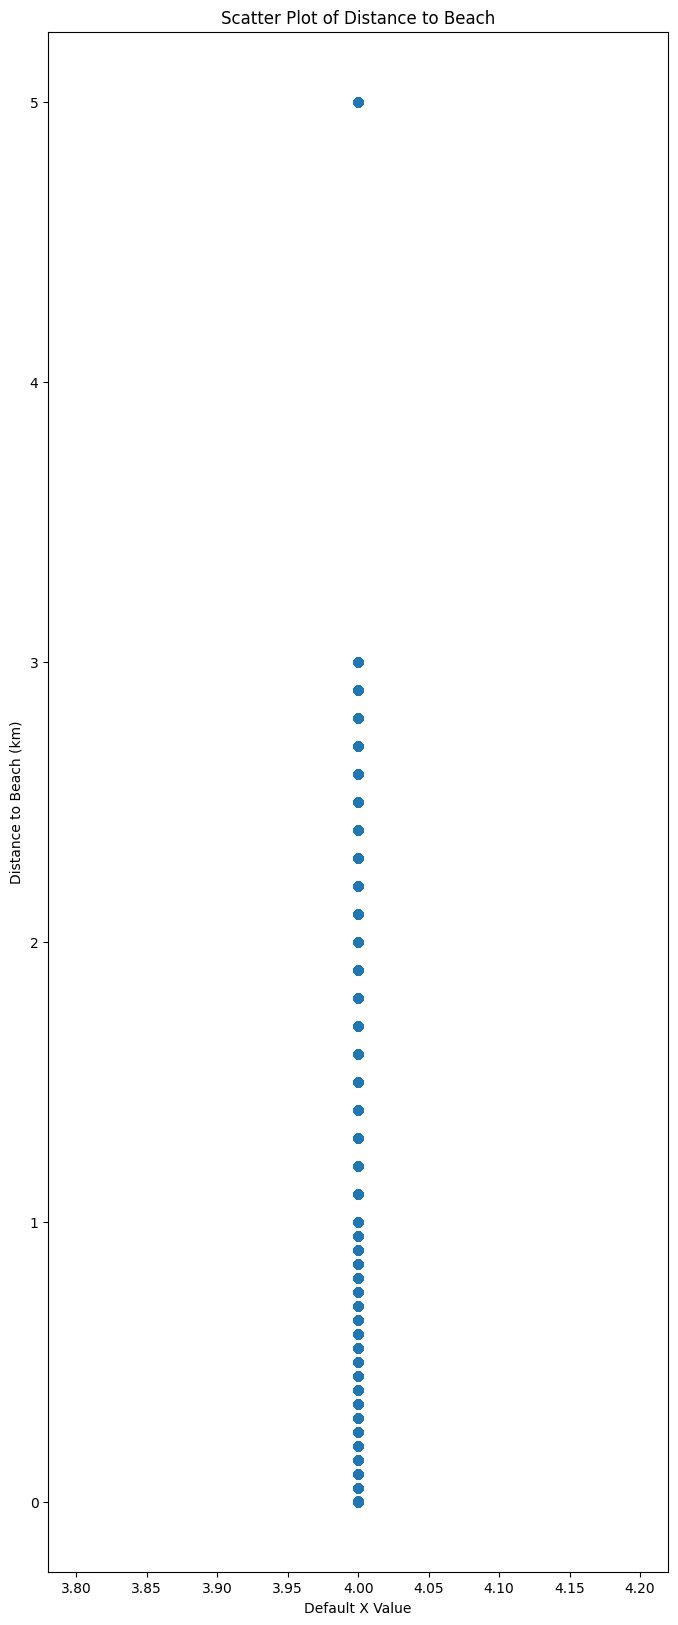

In [ ]:
#Điền giá trị
df['Distance_to_Beach'] = df['Distance_to_Beach'].fillna(5)

#Vẽ biểu đồ
plt.figure(figsize=(8, 20))
plt.scatter(x=[4] * len(df), y=df['Distance_to_Beach'])
plt.title('Scatter Plot of Distance to Beach')
plt.xlabel('Default X Value')
plt.ylabel('Distance to Beach (km)')
plt.show()


### Xử lý các đặc trưng về giá (giá phòng và thuế).  
- Trích xuất ra giá tiền và loại bỏ đơn vị vì tất cả giá đều chung đơn vị.  
- Đưa về đúng định dạng số thực.  
- Áp dụng với đặc trưng 'Price' và 'Taxes'  


In [ ]:
#Price
def extract_price(price):
    # Kiểm tra giá trị không hợp lệ
    if pd.isna(price):
        return None

    # loại bỏ "VND" và lấy số có dấu chấm
    match = re.match(r'.*?(\d{1,3}(?:\.\d{3})*(?:,\d+)?)', price, re.IGNORECASE)
    if not match:
        print(f"Định dạng không hợp lệ: '{price}'")
        return None

    # Lấy số và loại bỏ dấu chấm
    num_str = match.group(1).replace('.', '')

    # Chuyển thành float
    num = float(num_str)

    return num

df['Price'] = df['Price'].apply(extract_price)

In [ ]:
#Taxes

def extract_taxes(taxes):
    # Kiểm tra giá trị không hợp lệ
    if pd.isna(taxes):
        return None

    # Kiểm tra các trường hợp đặc biệt
    if taxes.lower() in ['đã bao gồm thuế và phí', 'da bao gom thue va phi',
                         'chỗ nghỉ có thể thu phụ phí', 'cho nghi co the thu phu phi']:
        return 0.0

    # Tìm số bằng regex (hỗ trợ cả dấu chấm và dấu phẩy)
    match = re.match(r'.*?(\d{1,3}(?:[,\.]\d{3})*(?:,\d+)?)', taxes, re.IGNORECASE)
    if not match:
        print(f"Định dạng không hợp lệ: '{taxes}'")
        return None

    # Lấy số và loại bỏ dấu chấm hoặc dấu phẩy
    num_str = match.group(1).replace('.', '').replace(',', '')
    num = float(num_str)
    return num

df['Taxes'] = df['Taxes'].apply(extract_taxes)

### Xử lý các đặc trưng về điểm đánh giá.
- Đưa về đúng định dạng số và dấu do kiểu dữ liệu bị sai trong quá trình thu thập dữ liệu.  

In [ ]:
Point_col = ['Point', 'staff', 'convenient', 'clean', 'comfort', 'worthwhile', 'destination']
def process_point(point):
    # Kiểm tra giá trị không hợp lệ
    if pd.isna(point):
        return None

    # Thay dấu phẩy thành dấu chấm
    point = point.replace(',', '.')

    # Chuyển thành float
    try:
        num = float(point)
        return num
    except ValueError:
        print(f"Định dạng không hợp lệ: '{point}'")
        return None

for col in Point_col:
    df[col] = df[col].apply(process_point)

### Xử lý cột đặc trưng về mức độ đánh giá của khách hàng.  
- Tạo mức độ phân cấp của của cách đánh giá và sử dụng Ordinal Encoding.  

In [ ]:
# Evaluate

Evaluate_rank = ['Điểm đánh giá', 'Tốt', 'Rất tốt', 'Tuyệt vời', 'Tuyệt hảo', 'Xuất sắc']
Ordinal_enc = OrdinalEncoder(categories=[Evaluate_rank], dtype = int)

print('Evaluate before enc:{}'.format(df['Evaluate'].unique()))
df['Evaluate'] = Ordinal_enc.fit_transform(df[['Evaluate']])
print('Evaluate after enc:{}'.format(df['Evaluate'].unique()))

Evaluate before enc:['Rất tốt' 'Tuyệt vời' 'Tuyệt hảo' 'Xuất sắc' 'Tốt' 'Điểm đánh giá']
Evaluate after enc:[2 3 4 5 1 0]


### Xử lý đặc trưng về số lượng đánh giá của khách hàng.  
- Trích xuất ra số đánh giá của khách hàng.  

In [ ]:
# Rates Quantity

def extract_quantity(quantity):
    # Kiểm tra giá trị không hợp lệ
    if pd.isna(quantity):
        return None

    # Tìm số bằng regex
    match = re.match(r'(\d{1,3}(?:\.\d{3})*)', quantity, re.IGNORECASE)
    if not match:
        print(f"Định dạng không hợp lệ: '{quantity}'")
        return None  # Hoặc giá trị mặc định

    # Lấy số và loại bỏ dấu chấm
    num_str = match.group(1).replace('.', '')

    # Chuyển thành float
    num = float(num_str)
    return num

df['Rates_Quantity'] = df['Rates_Quantity'].apply(extract_quantity)

### Xử lý các đặc trưng về ngày tháng.  
- Chuyển về đúng định dạng
- Trích xuất ra đặc trung 'day' và 'month' của ngày checkin để xác định ngày ở.  
- Thêm đặc trưng 'is_weekend' (ngày cuối tuần) và 'is_special_day' (ngày đặc biệt).  
- Tính khoảng thời gian từ ngày crawl dữ liệu đến ngày đặt phòng.  

In [ ]:
# Chuyển Checkin, Checkout thành dạng datetime

df['Checkin'].astype(str)
df['Checkout'].astype(str)
df['Crawl_date'].astype(str)
df['Checkin'] = pd.to_datetime(df['Checkin'], errors='coerce')
df['Checkout'] = pd.to_datetime(df['Checkout'], errors='coerce')
df['Crawl_date'] = pd.to_datetime(df['Crawl_date'], errors='coerce')

# Tách cột Checkin thành cột day và month
df['day'] = df['Checkin'].dt.day
df['month'] = df['Checkin'].dt.month

def is_weekend(date):
    return int(date.weekday() >= 5) if pd.notna(date) else 0

df['is_weekend'] = df['Checkin'].apply(is_weekend)

In [ ]:
#Tính khoảng thời gian từ ngày đặt phòng(Crawl_date) đến ngày checkin (Checkin)
df['day_range'] = (df['Checkin'] - df['Crawl_date']).dt.days

In [ ]:
# Xử lý các cột ngày thuộc dịp đặc biệt

special_day = {
    'all': [
        '2025-05-01',  # Quốc tế Lao động
    ],
    'da nang': [
        '2025-05-31',  # Khai mạc Lễ hội Pháo hoa Quốc tế Đà Nẵng
        '2025-07-12',  # Đêm chung kết Pháo hoa
        '2025-07-16',  # Lễ hội Tận hưởng - ngày 1
        '2025-07-17',  # Lễ hội Tận hưởng - ngày 2
        '2025-07-18',  # Lễ hội Tận hưởng - ngày 3
        '2025-07-19',  # Lễ hội Tận hưởng - ngày 4
        '2025-07-20',  # Lễ hội Tận hưởng - ngày 5
    ],
    'nha trang': [
        '2025-06-03',  # Khai mạc Lễ hội Trầm Hương
        '2025-06-04',  # Lễ hội Ẩm thực Quốc tế
        '2025-06-05',  # Lễ hội Yến Sào
        '2025-06-07',  # Lễ hội Du lịch biển - ngày 1
        '2025-06-08',  # Lễ hội Du lịch biển - ngày 2
        '2025-06-09',  # Du lịch biển - ngày 3 + Carnival
    ],
    'quy nhon': [
        '2025-06-13',  # Du lịch hè Bình Định
        '2025-06-14',  # VnExpress Marathon - ngày 1
        '2025-06-15',  # VnExpress Marathon - ngày 2
    ],
    'hoi an': [
        '2025-05-22',  # Đêm rằm tháng 4
        '2025-06-20',  # Đêm rằm tháng 5
        '2025-07-20',  # Đêm rằm tháng 6
        '2025-08-18',  # Đêm rằm tháng 7
    ],
    'ha long': [
        '2025-05-01',  # Có thể có Carnaval Hạ Long
    ],
    'dao cat ba': [
        '2025-05-01',  # Có thể có Lễ hội Cát Bà
    ],
    'dong hoi': [
        '2025-07-01',  # Lễ hội Hang động Quảng Bình - dự kiến
        '2025-08-01',  # Lễ hội Hang động Quảng Bình - dự kiến
    ],
    'vung tau': [
        '2025-07-10',  # V-Fest 2025 (dự kiến)
    ],
    'mui ne': [],     # Không có sự kiện
    'phu quoc': [],   # Không có sự kiện
}

special_day_dt = defaultdict(set)
for dia_diem, ngay_list in special_day.items():
    special_day_dt[dia_diem] = set(datetime.strptime(ngay, '%Y-%m-%d').date() for ngay in ngay_list)

df['Checkin'] = pd.to_datetime(df['Checkin']).dt.date
def is_special_day(row):
    location = row['Address']
    date = row['Checkin']

    return int(
        date in special_day_dt.get(location, set()) or
        date in special_day_dt['all']
    )

df['is_special_day'] = df.apply(is_special_day, axis=1)

#Drop các cột đã được sử dụng
df.drop(['Checkin', 'Checkout','Crawl_date'], axis=1, inplace=True)

### Xử lý đặc trưng về đẳng cấp khách sạn:  
- Số sao của khách sạn là một đặc trưng thể hiện đẳng cấp của khách sạn đó theo các mức đọ 1-2-3-4-5.  
- Tùy vào việc đạt chuẩn các tiêu chí mà khách sạn sẽ đạt được mức độ sao nhất định.
- Việc xuất hiện các missing values ở thuộc tính 'Stars' là do các khách sạn không đạt bất cứ tiêu chuẩn nào về số sao hoặc một vài yếu tố khác. Do đó các khách sạn có giá trị số sao bị khuyết sẽ nằm ở mức 0 sao.


In [ ]:
df['Stars'] = df['Stars'].fillna(0)

### Xử lý đặc trưng về loại phòng:  
- Tách thành 3 đặc trưng là loại phòng, đẳng cấp và số lượng(giường-phòng)

In [ ]:
df_kind = df['Kind'].astype(str).fillna('')
df_kind = df_kind.str.lower()
df_kind.unique().tolist()

['phòng superior giường đôi',
 'phòng đôi superior',
 'phòng deluxe giường đôi có ban công',
 'studio có giường cỡ king',
 'phòng giường đôi hạng tiết kiệm',
 'phòng superior 2 giường đơn',
 'phòng giường đôi có ban công',
 'phòng superior 2 giường đơn nhìn ra cảnh thành phố',
 'phòng deluxe 2 giường đơn',
 'phòng 2 giường đơn nhìn ra thành phố',
 'phòng tiêu chuẩn 2 giường đơn',
 'phòng deluxe giường đôi nhìn ra thành phố - bao gồm trà chiều hằng ngày',
 'phòng superior 2 giường đơn có cửa sổ nhỏ nhìn ra thành phố',
 'phòng superior có giường cỡ king',
 'phòng superior có 2 giường đơn với cửa sổ',
 'phòng deluxe 2 giường đơn nhìn ra đường phố',
 'phòng premier giường đôi nhìn ra cảnh thành phố',
 'phòng deluxe 2 giường đơn nhìn ra biển',
 'phòng superior giường đôi/2 giường đơn',
 'phòng tiêu chuẩn có 2 giường cỡ queen',
 'phòng deluxe giường đôi hoặc 2 giường đơn với bồn tắm spa',
 'phòng superior giường đôi/2 giường đơn nhìn ra thành phố',
 'studio tiêu chuẩn',
 'phòng gi

In [ ]:
# tìm những dòng chứa chữ room trong df_kind
df_kind[df_kind.fillna('').str.contains('room')]

,Kind
42,superior room with bathtub
61,standard queen room internal window
88,superior double room with city view
90,nova double or twin room with private balcony
91,deluxe twin room garden view
...,...
282349,premium family room with resort view - executi...
282438,3-bedroom premier residence ocean
282461,3 bedrooms deluxe garden view villa
282468,two-bedroom residence city vista


In [ ]:
df_kind = df_kind.str.replace('room', 'phòng')
df_kind = df_kind.str.replace('apartment', 'căn hộ')
df_kind = df_kind.str.replace('house', 'căn hộ')
df_kind = df_kind.str.replace('nhà', 'căn hộ')
df_kind = df_kind.str.replace('standard', 'tiêu chuẩn')
df_kind.unique().tolist()

['phòng superior giường đôi',
 'phòng đôi superior',
 'phòng deluxe giường đôi có ban công',
 'studio có giường cỡ king',
 'phòng giường đôi hạng tiết kiệm',
 'phòng superior 2 giường đơn',
 'phòng giường đôi có ban công',
 'phòng superior 2 giường đơn nhìn ra cảnh thành phố',
 'phòng deluxe 2 giường đơn',
 'phòng 2 giường đơn nhìn ra thành phố',
 'phòng tiêu chuẩn 2 giường đơn',
 'phòng deluxe giường đôi nhìn ra thành phố - bao gồm trà chiều hằng ngày',
 'phòng superior 2 giường đơn có cửa sổ nhỏ nhìn ra thành phố',
 'phòng superior có giường cỡ king',
 'phòng superior có 2 giường đơn với cửa sổ',
 'phòng deluxe 2 giường đơn nhìn ra đường phố',
 'phòng premier giường đôi nhìn ra cảnh thành phố',
 'phòng deluxe 2 giường đơn nhìn ra biển',
 'phòng superior giường đôi/2 giường đơn',
 'phòng tiêu chuẩn có 2 giường cỡ queen',
 'phòng deluxe giường đôi hoặc 2 giường đơn với bồn tắm spa',
 'phòng superior giường đôi/2 giường đơn nhìn ra thành phố',
 'studio tiêu chuẩn',
 'phòng gi

In [ ]:
#accommodation_keywords = ['căn hộ', 'biệt thự', 'phòng', 'bungalow', 'villa', 'studio', 'resort', 'nhà nghỉ', 'suite']
#room_level_keywords = ['deluxe', 'premium', 'cao cấp', 'gia đình', 'thường', 'executive', 'superior']

accommodation_keywords_room = ['phòng', 'nhà nghỉ', 'suite', 'studio']
accommodation_keywords_apartment = ['biệt thự', 'villa', 'căn hộ', 'bungalow', 'resort']
room_level_keywords = ['deluxe', 'premium', 'cao cấp', 'gia đình', 'chuẩn', 'executive', 'superior']

In [ ]:
# bóc tách đặc trưng loại cư tru
def extract_accommodation(kind):
    kind = str(kind)
    kind = unicodedata.normalize('NFC', kind)
    # thực hiện tìm theo âprtment trước cho nó chính xác hơn
    for kw in accommodation_keywords_apartment:
        if kw in kind.lower():
            return kw
    for kw in accommodation_keywords_room:
        if kw in kind.lower():
            return kw
    return 'khác'

In [ ]:
# bóc tách đặc trưng đẳng cấp (premium, deluxe,....)
def extract_room_level(kind):
    kind = str(kind)
    kind = unicodedata.normalize('NFC', kind)
    for kw in room_level_keywords:
        if (kw == 'chuẩn') and (kw in kind.lower()):
            return 'tiêu chuẩn'
        if kw in kind.lower():
            return kw
    return 'khác'

In [ ]:
# bóc tách số giường, số phòng
def extract_quantity(kind, accommodation_type):
    text = kind.lower()
    text = unicodedata.normalize('NFC', text)

    # nếu là loại phòng thì tìm giường
    if accommodation_type in accommodation_keywords_room:
        # ưu tiên tìm số lượng cụ thể
        match = re.search(r'(\d+)\s*(giường|bed)', text)
        if match:
            return f'{match.group(1)} giường'

        # nếu không thấy số thì tìm các từ chỉ loại giường
        if re.search(r'giường đôi|double bed', text):
            return '1 giường đôi'
        elif re.search(r'giường đơn|single bed', text):
            return '1 giường đơn'
        elif re.search(r'giường', text) or re.search(r'bed', text):
            return '1 giường'

        return 'không rõ'

    # nếu là biệt thự, căn hộ thì tìm số phòng
    elif accommodation_type in accommodation_keywords_apartment:
        match = re.search(r'(\d+)\s*(phòng|room)', text) # chỗ này thêm trường hợp room tại vì ở trên đã thực hiện replace nhưng k hỉu sao vẫn có 1 vài dòng nó k replace
        if match:
            return f'{match.group(1)} phòng'

        # Có thể giả định mặc định là 1 phòng nếu xuất hiện 'phòng'
        if re.search(r'phòng|room', text):
            return '1 phòng'

        return 'không rõ'

    return 'không rõ'


In [ ]:
#Tạo đặc trưng mới
df['Accommodation_Type'] = df_kind.apply(extract_accommodation)
df['Room_Level'] = df_kind.apply(extract_room_level)
kind_column = df['Kind']
df['Room/Bed Quantity'] = df.apply(lambda row: extract_quantity(row['Kind'], row['Accommodation_Type']), axis=1)
#Drop đặc trưng cũ
df.drop('Kind', axis=1, inplace=True)

### Xử lý đặc trưng về tên khách sạn.  
- Loại bỏ các từ ngữ dư thừa trong tên (địa danh, ưu đãi,...)

In [ ]:
stopwords_path = '/content/drive/My Drive/Đồ án/vietnamese-stopwords.txt'
stopwords_vietnamese = set()
with open(stopwords_path, 'r', encoding='utf-8') as f:
    stopwords_vietnamese = set([line.strip() for line in f])

In [ ]:
# Loại bỏ 2 khoảng trắng đầu tiên và chuyển sang chữ thường
df['Name'] = df['Name'].str.strip().str.lower()
df['Name'] = df['Name'].str.replace('&', 'and')
df['Name']=df['Name'].str.replace('-',' ')
df['Name']=df['Name'].str.replace("'",' ')
Main_location_list = ['đà nẵng', 'danang', 'da nang', 'nhatrang', 'nha trang','phú quốc','phuquoc', 'phu quoc','mũi né', 'muine', 'mui ne','vũng tàu', 'vungtau', 'vung tau','hội an', 'hoian', 'hoi an', 'quy nhơn', 'quynhon', 'quy nhon', 'hạ long', 'halong', 'ha long', 'đảo cát bà', 'daocatba', 'dao cat ba','đồng hới', 'donghoi', 'dong hoi', 'quảng bình', 'quang binh', 'quangbinh']
en_stopwords = stopwords.words('english')

# Tách câu nếu lớn hơn 2 khoảng trắng và giữ lại câu đầu tiên
def split_sentences(text):
    sentences = text.split('  ')
    return sentences[0]
df['Name']=df['Name'].apply(split_sentences)

# Loại bỏ các ký tự đặc biệt và phần đứng sau nó
import re
def remove_irrelevant_info(text):
  # Tìm phần trước ký tự đặc biệt hoặc dấu câu
  match = re.split(r"[^\w\sÀ-Ỹà-ỹ']", text, maxsplit=1)
  return match[0].strip()

df['Name']=df['Name'].apply(remove_irrelevant_info)

# Loại bỏ stopword trong tiếng anh
def remove_stopwords_english(text):
  if isinstance(text, str):
    tokens = en_tokenizer(text)
    filtered_tokens = [word for word in tokens if word not in en_stopwords]
    return ' '.join(filtered_tokens)
  return text

df['Name'] = df['Name'].apply(remove_stopwords_english)

# Loại bỏ stopword trong tiếng việt
def remove_stopwords_vietnamese(text):
  if isinstance(text, str):
    tokens = vi_tokenizer(text)
    filtered_tokens = [word for word in tokens if word not in stopwords_vietnamese]
    return ' '.join(filtered_tokens)
  return text

df['Name'] = df['Name'].apply(remove_stopwords_vietnamese)

# Duyệt qua từng dòng và loại bỏ các từ trong Main_location_list
def remove_location_words(name):
    words = vi_tokenizer(name,fixed_words=Main_location_list)
    filtered_words = [word for word in words if word not in Main_location_list]
    return ' '.join(filtered_words)

df['Name'] = df['Name'].apply(remove_location_words)


## Kiểm tra lại dữ liệu sau khi đã tiền xử lý

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274859 entries, 0 to 282506
Data columns (total 39 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Name                         274859 non-null  object 
 1   Address                      274859 non-null  object 
 2   Distance_to_DownTown         274859 non-null  float64
 3   Distance_to_Beach            274859 non-null  float64
 4   Price                        274859 non-null  float64
 5   Taxes                        274859 non-null  float64
 6   Point                        274859 non-null  float64
 7   Evaluate                     274859 non-null  int64  
 8   Stars                        274859 non-null  float64
 9   Rates_Quantity               274859 non-null  float64
 10  view_to_beach                274859 non-null  float64
 11  view_to_city                 274859 non-null  float64
 12  view_to_mountain             274859 non-null  float64
 13  view

In [ ]:
missing_values(df)

,Missing Count,Missing Percent


In [ ]:
df.to_csv('Silver_data.csv', index=False)